# Classification Algorithms — KNN, Decision Tree, Random Forest, Logistic Regression, Naive Bayes, SVM

*Part of the ML Course Reference Series.*

## Q9: How does K-Nearest Neighbors (KNN) work?

For a new point, KNN finds the K closest training examples (by distance) and takes a majority vote among their labels.

**Key hyperparameters:**
- `n_neighbors` (K) — small K → complex boundary (risk overfitting); large K → smoother (risk underfitting)
- `weights` — `'uniform'` (all neighbours equal) vs `'distance'` (closer ones count more)

**Requires scaling** — distance is meaningless if features are on different scales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
sns.set_theme(style='whitegrid')
np.random.seed(42)
from sklearn.datasets import load_iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
from sklearn.datasets import load_breast_cancer
_cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = _cancer.data, _cancer.target


In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

results = {}
for k in [1, 5, 15, 30]:
    pipe = Pipeline([('scl', StandardScaler()),
                     ('knn', KNeighborsClassifier(n_neighbors=k))])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    results[k] = round(score, 3)

print('K → CV accuracy')
for k, s in results.items():
    print(f'  K={k:2d}: {s}')

K → CV accuracy
  K= 1: 0.954
  K= 5: 0.965
  K=15: 0.961
  K=30: 0.953


## Q10: How does a Decision Tree work?

A decision tree repeatedly splits the data on the feature + threshold that best separates the classes. At each node it asks a yes/no question (e.g. `petal_length < 2.45`). Leaf nodes hold the final predictions.

**Split criteria:**
- `gini` — measures impurity: 0 = pure node, 0.5 = maximum impurity
- `entropy` — information gain; slightly slower but often similar results

**Key hyperparameters:** `max_depth`, `min_samples_split`, `min_samples_leaf`

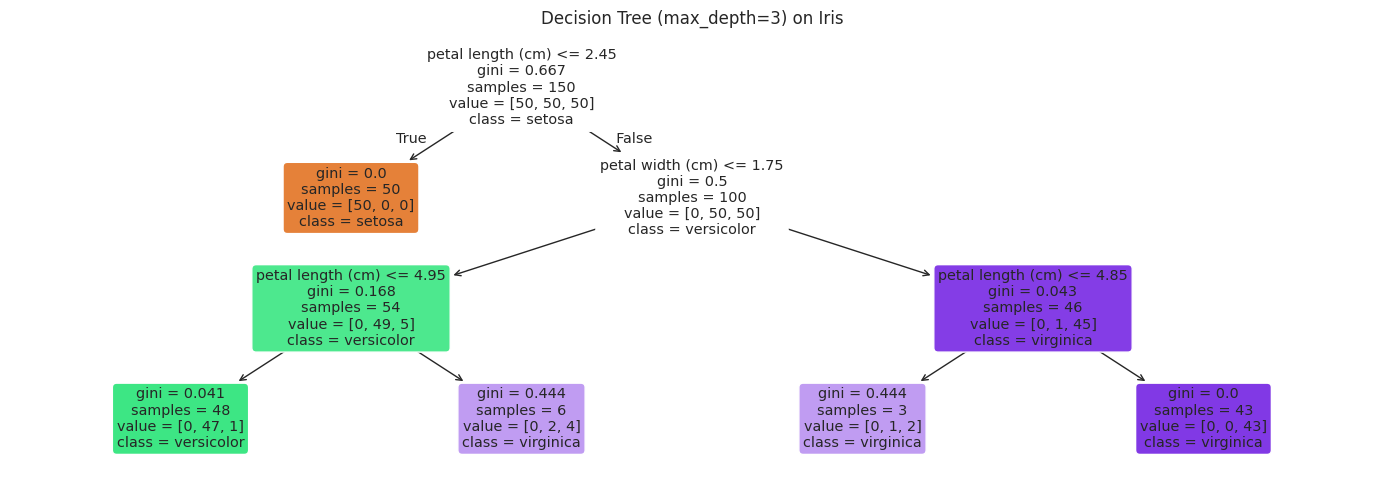

Train accuracy: 0.973
CV accuracy:    0.973


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt.fit(X_iris, y_iris)

plt.figure(figsize=(14, 5))
plot_tree(dt, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True)
plt.title('Decision Tree (max_depth=3) on Iris')
plt.tight_layout()
plt.show()

print('Train accuracy:', round(dt.score(X_iris, y_iris), 3))
print('CV accuracy:   ', round(cross_val_score(dt, X_iris, y_iris, cv=5).mean(), 3))

## Q10b: Gini Impurity vs Entropy — what's the difference and which should you use?

Both measure **node impurity** — how mixed the classes are at a split. A pure node (one class only) scores 0 on both.

| | Formula | Range | Speed |
|---|---|---|---|
| **Gini** | `1 - Σ pᵢ²` | [0, 0.5] for binary | Faster (no log) |
| **Entropy** | `-Σ pᵢ log₂(pᵢ)` | [0, 1] for binary | Slightly slower |

**In practice:** both almost always produce the same tree structure and similar accuracy. Default to `gini` (faster). Switch to `entropy` if you care about information-theoretic interpretability.

A split is chosen to **maximise Information Gain** = impurity(parent) − weighted average impurity(children).

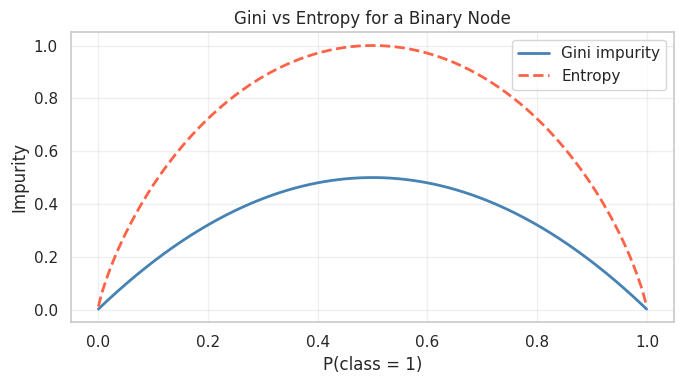

Parent gini:      0.5000
Left  gini:       0.2778  (6 samples: 5A, 1B)
Right gini:       0.0000  (4 samples: 0B, 4B = pure!)
Weighted child:   0.1667
Information Gain: 0.3333  ← the tree maximises this

CV accuracy comparison on Breast Cancer:
  criterion=gini   : 0.9191
  criterion=entropy: 0.9350
(difference is typically negligible)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# ── 1. Gini vs Entropy formula comparison ────────────────────────────────────
p = np.linspace(0.001, 0.999, 300)   # p = prob of class 1
gini    = 1 - (p**2 + (1-p)**2)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))

plt.figure(figsize=(7, 4))
plt.plot(p, gini,    label='Gini impurity', color='steelblue', linewidth=2)
plt.plot(p, entropy, label='Entropy',       color='tomato',    linewidth=2, linestyle='--')
plt.xlabel('P(class = 1)')
plt.ylabel('Impurity')
plt.title('Gini vs Entropy for a Binary Node')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Information Gain example (manual) ─────────────────────────────────────
# Parent: 10 samples, 5 class-A, 5 class-B  → impurity = 0.5
# Split into Left (6 samples: 5A, 1B) and Right (4 samples: 0A, 4B)
def gini_node(pos, total):
    if total == 0: return 0
    p = pos / total
    return 1 - p**2 - (1-p)**2

parent_gini = gini_node(5, 10)
left_gini   = gini_node(5, 6)
right_gini  = gini_node(0, 4)
weighted    = (6/10) * left_gini + (4/10) * right_gini
info_gain   = parent_gini - weighted

print(f'Parent gini:      {parent_gini:.4f}')
print(f'Left  gini:       {left_gini:.4f}  (6 samples: 5A, 1B)')
print(f'Right gini:       {right_gini:.4f}  (4 samples: 0B, 4B = pure!)')
print(f'Weighted child:   {weighted:.4f}')
print(f'Information Gain: {info_gain:.4f}  ← the tree maximises this')

# ── 3. Accuracy comparison: gini vs entropy ───────────────────────────────────
print('\nCV accuracy comparison on Breast Cancer:')
for criterion in ['gini', 'entropy']:
    dt = DecisionTreeClassifier(max_depth=5, criterion=criterion, random_state=42)
    score = cross_val_score(dt, X_cancer, y_cancer, cv=5).mean()
    print(f'  criterion={criterion:7s}: {score:.4f}')
print('(difference is typically negligible)')

## Q11: What is Random Forest and why is it better than a single Decision Tree?

Random Forest trains many decision trees on **random subsets** of data (bagging) and random subsets of features. Predictions are made by majority vote across all trees.

**Why it's better:**
- A single deep tree overfits. Many trees averaging out their errors gives a more stable prediction.
- The feature randomness (`max_features`) ensures trees are diverse and their errors are uncorrelated.

**Key hyperparameters:** `n_estimators` (more = better, but slower), `max_depth`, `max_features`

In [5]:
from sklearn.ensemble import RandomForestClassifier

single_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

dt_scores = cross_val_score(single_tree,  X_cancer, y_cancer, cv=5)
rf_scores  = cross_val_score(random_forest, X_cancer, y_cancer, cv=5)

print(f'Single Tree CV: {dt_scores.mean():.3f} ± {dt_scores.std():.3f}')
print(f'Random Forest CV: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}')
# RF should be higher accuracy AND lower std (more stable)

Single Tree CV: 0.917 ± 0.024
Random Forest CV: 0.956 ± 0.023


## Q12: What is Logistic Regression? (Despite the name, it's a classifier.)

Logistic Regression models the **probability** of a class using the sigmoid function:

```
P(y=1 | x) = 1 / (1 + e^(-w·x))
```

If P > 0.5 → class 1, else class 0. Unlike a Decision Tree, the decision boundary is a straight line (linear).

**Hyperparameter `C`:** inverse of regularisation strength. Small C = more regularisation (simpler model).

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scl', StandardScaler()),
    ('lr',  LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])

scores = cross_val_score(pipe, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'Logistic Regression CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Inspect learned coefficients (after fitting on full data)
pipe.fit(X_cancer, y_cancer)
coef = pipe.named_steps['lr'].coef_[0]
top5 = pd.Series(np.abs(coef), index=X_cancer.columns).nlargest(5)
print('\nTop 5 most influential features:')
print(top5.round(3))

Logistic Regression CV: 0.981 ± 0.007

Top 5 most influential features:
worst texture    1.321
radius error     1.289
worst radius     1.027
area error       0.999
worst area       0.995
dtype: float64


## Q13: What is Naive Bayes?

Naive Bayes applies Bayes' theorem with the "naive" assumption that features are **independent** given the class:

```
P(class | features) ∝ P(class) × ∏ P(feature_i | class)
```

This is almost never true in real data, but the classifier still works surprisingly well — especially for text classification.

**Variants:**
- `GaussianNB` — numeric features assumed to be normally distributed
- `MultinomialNB` — word counts (text)
- `BernoulliNB` — binary features

In [7]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
scores = cross_val_score(nb, X_cancer, y_cancer, cv=5, scoring='accuracy')
print(f'GaussianNB CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Bayes' theorem example (manual)
# P(disease | positive test) given:
p_disease  = 0.01   # prevalence
p_pos_given_disease = 0.99   # sensitivity
p_pos_given_no_disease = 0.05  # false positive rate

p_pos = p_pos_given_disease * p_disease + p_pos_given_no_disease * (1 - p_disease)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f'\nBayes example: P(disease | positive test) = {p_disease_given_pos:.3f}')
print('Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%')

GaussianNB CV: 0.939 ± 0.015

Bayes example: P(disease | positive test) = 0.167
Even with a 99% accurate test, only ~17% chance of disease when prevalence is 1%


## Q14: What is Support Vector Machine (SVM)?

SVM finds the **maximum-margin hyperplane** — the decision boundary that is as far as possible from the nearest data points (support vectors) of each class.

**The kernel trick** maps data to a higher-dimensional space, allowing non-linear boundaries without explicitly computing the transformation.

**Key hyperparameters:**
- `C` — trade-off between margin width and misclassification
- `kernel` — `'linear'`, `'rbf'` (most common), `'poly'`
- `gamma` — how far the influence of each training point reaches (for rbf)

In [8]:
from sklearn.svm import SVC

# SVM requires scaling
for kernel in ['linear', 'rbf']:
    pipe = Pipeline([
        ('scl', StandardScaler()),
        ('svm', SVC(kernel=kernel, C=1.0, random_state=42))
    ])
    score = cross_val_score(pipe, X_cancer, y_cancer, cv=5).mean()
    print(f'SVM ({kernel:6s}) CV accuracy: {score:.3f}')

SVM (linear) CV accuracy: 0.972


SVM (rbf   ) CV accuracy: 0.974


---
# 4. Regression Algorithms